# Erkennung der Schweißqualität während des Schweißprozesses

## Entwicklung eines datengetriebenen Verfahrens zur Überwachung und Vorhersage der Schweißqualität anhand von induktiven Tasterdaten und thermischen LWIR-Aufnahmen

In [264]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image
import math

## Taster-Zeitreihen analysieren:

#### Wie bewegen sich Taster 1, 2 und 3 während einer Schweißung (Konfiguration 001)?

In [265]:
# Betrachtung: 001-000 (Preprocessed)

pfad001_000Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/001/001-000.npy")

fuerDataFrame = np.load(pfad001_000Prep)

df001_000Prep = pd.DataFrame(
    {
        "Time (s)": fuerDataFrame[0],
        "Taster 1 (mm)": fuerDataFrame[1],
        "Taster 2 (mm)": fuerDataFrame[2],
        "Taster 3 (mm)": fuerDataFrame[3]
    }
)

display(df001_000Prep[: 100])

print(df001_000Prep.shape)

,Time (s),Taster 1 (mm),Taster 2 (mm),Taster 3 (mm)
0,1.134,0.020373,0.012720,0.003004
1,1.135,0.020452,0.012877,0.003161
2,1.136,0.020530,0.013034,0.003396
3,1.137,0.020687,0.013270,0.003553
4,1.138,0.020530,0.013505,0.003710
...,...,...,...,...
95,1.229,0.032382,0.051413,0.069559
96,1.230,0.032539,0.051806,0.070501
97,1.231,0.032539,0.052198,0.071050
98,1.232,0.032853,0.052905,0.071757


(19909, 4)


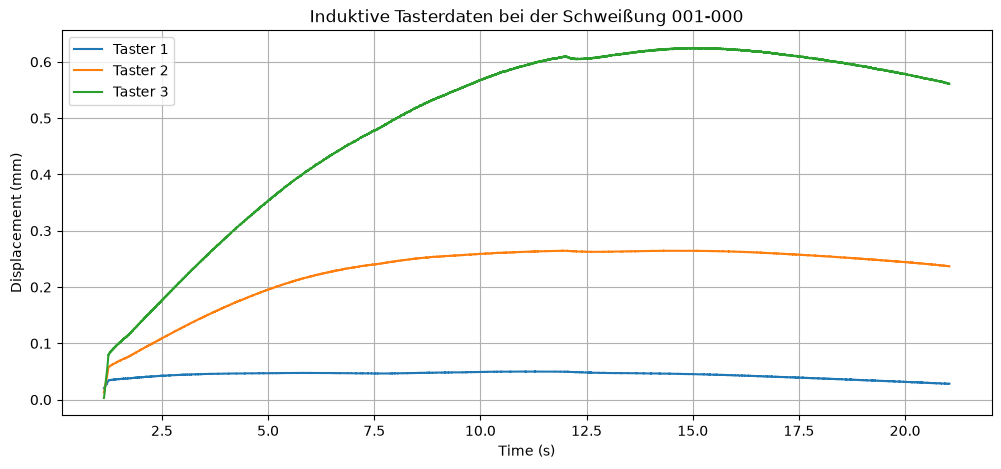

In [266]:
plt.figure(figsize = (12, 5))

plt.plot(df001_000Prep["Time (s)"], df001_000Prep["Taster 1 (mm)"], label="Taster 1")
plt.plot(df001_000Prep["Time (s)"], df001_000Prep["Taster 2 (mm)"], label="Taster 2")
plt.plot(df001_000Prep["Time (s)"], df001_000Prep["Taster 3 (mm)"], label="Taster 3")

plt.xlabel("Time (s)")
plt.ylabel("Displacement (mm)")
plt.title("Induktive Tasterdaten bei der Schweißung 001-000")
plt.legend()
plt.grid()

plt.show()

##### -> Starke Positionsänderungen in Y-Richtung vor allem bei Taster 3. Taster 3 befindet sich an der rechten bzw. endseitigen Messposition des beweglichen Blechs.

#### Und wenn man alle 50 Schweißungen vergleicht innerhalb der Konfiguration 001?

##### Problem:

In [267]:
pfad000Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/001/001-000.npy")
pfad015Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/001/001-015.npy")

daten000 = np.load(pfad000Prep)
daten015 = np.load(pfad015Prep)

print("001-000 Shape:", daten000.shape)
print("001-015 Shape:", daten015.shape)

001-000 Shape: (4, 19909)
001-015 Shape: (3, 19280)


In [268]:
df000Prep = pd.DataFrame(daten000.T)
df015Prep = pd.DataFrame(daten015.T)

print("001-000:")
display(df000Prep.head(5))

print("001-015:")
display(df015Prep.head(5))

001-000:


,0,1,2,3
0,1.134,0.020373,0.012720,0.003004
1,1.135,0.020452,0.012877,0.003161
2,1.136,0.020530,0.013034,0.003396
3,1.137,0.020687,0.013270,0.003553
4,1.138,0.020530,0.013505,0.003710


001-015:


,0,1,2
0,-0.000094,-0.000060,-0.000037
1,-0.000173,-0.000060,-0.000115
2,-0.000251,-0.000060,-0.000115
3,-0.000173,0.000018,-0.000037
4,-0.000094,-0.000138,-0.000115


##### Shape hat sich verändert ab 015, kein Zeitstempel vorhanden. Bei der Konfiguration 001 hat man auf die ersten 15 einen Zeitstempel und danach nicht mehr.

##### Andere Vorgehensweise um die 50 Schweißungen miteinander zu vergleichen aus Konfiguration 001.

#### Konfiguration 002 hat auch das gleiche Problem?

In [269]:
pfad001Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/001")
pfad002Prep = Path("../data/Dataset/Preprocessed/Inductiv_Probes/002")

print("001 Shape Kontrolle der .npy Dateien:")
print()

for datei in sorted(pfad001Prep.glob("*.npy")):
    daten = np.load(datei)
    print(datei.name, daten.shape)

print()
print("002 Shape Kontrolle der .npy Dateien:")
print()

for datei in sorted(pfad002Prep.glob("*.npy")):
    daten = np.load(datei)
    print(datei.name, daten.shape)

001 Shape Kontrolle der .npy Dateien:

001-000.npy (4, 19909)
001-001.npy (4, 19496)
001-002.npy (4, 19762)
001-003.npy (4, 19588)
001-004.npy (4, 19833)
001-005.npy (4, 19933)
001-006.npy (4, 19660)
001-007.npy (4, 19887)
001-008.npy (4, 19869)
001-009.npy (4, 19126)
001-010.npy (4, 19916)
001-011.npy (4, 19516)
001-012.npy (4, 19801)
001-013.npy (4, 19816)
001-014.npy (4, 19852)
001-015.npy (3, 19280)
001-016.npy (3, 19280)
001-017.npy (3, 19280)
001-018.npy (3, 19280)
001-019.npy (3, 19280)
001-020.npy (3, 19280)
001-021.npy (3, 19280)
001-022.npy (3, 19280)
001-023.npy (3, 19280)
001-024.npy (3, 19279)
001-025.npy (3, 19279)
001-026.npy (3, 19280)
001-027.npy (3, 19280)
001-028.npy (3, 19280)
001-029.npy (3, 19280)
001-030.npy (3, 19279)
001-031.npy (3, 19279)
001-032.npy (3, 19279)
001-033.npy (3, 19280)
001-034.npy (3, 19280)
001-035.npy (3, 19280)
001-036.npy (3, 19280)
001-037.npy (3, 19280)
001-038.npy (3, 19280)
001-039.npy (3, 19280)
001-040.npy (3, 19280)
001-041.npy (3, 19

##### Beide Konfigurationen haben ab 015 Shape (3, n).

##### -> Bei Shape (3, n) wird die extra Zeitstempel-Spalte künstlich erzeugt um Shape zu erweitern.

In [270]:
alleDataFrames001 = []

for datei in sorted(pfad001Prep.glob("*.npy")):

    daten = np.load(datei).T

    if daten.shape[1] == 4:

        df = pd.DataFrame(
            daten,
            columns = [
                "Time (s)",
                "Taster 1 (mm)",
                "Taster 2 (mm)",
                "Taster 3 (mm)"
            ]
        )

        df["Time Type"] = "original"

    elif daten.shape[1] == 3:

        df = pd.DataFrame(
            daten,
            columns = [
                "Taster 1 (mm)",
                "Taster 2 (mm)",
                "Taster 3 (mm)"
            ]
        )

        df["Time (s)"] = np.arange(len(df)) / 1000
        df["Time Type"] = "reconstructed"

    df["ID"] = datei.stem

    df = df[ # Reihenfolge ändern
        [
            "ID",
            "Time (s)",
            "Time Type",
            "Taster 1 (mm)",
            "Taster 2 (mm)",
            "Taster 3 (mm)"
        ]
    ]

    alleDataFrames001.append(df)

dataFrameAlleDataFrames001 = pd.concat(alleDataFrames001, ignore_index = True)

display(dataFrameAlleDataFrames001.head(100))
print("Shape: ", dataFrameAlleDataFrames001.shape)

,ID,Time (s),Time Type,Taster 1 (mm),Taster 2 (mm),Taster 3 (mm)
0,001-000,1.134,original,0.020373,0.012720,0.003004
1,001-000,1.135,original,0.020452,0.012877,0.003161
2,001-000,1.136,original,0.020530,0.013034,0.003396
3,001-000,1.137,original,0.020687,0.013270,0.003553
4,001-000,1.138,original,0.020530,0.013505,0.003710
...,...,...,...,...,...,...
95,001-000,1.229,original,0.032382,0.051413,0.069559
96,001-000,1.230,original,0.032539,0.051806,0.070501
97,001-000,1.231,original,0.032539,0.052198,0.071050
98,001-000,1.232,original,0.032853,0.052905,0.071757


Shape:  (970757, 6)


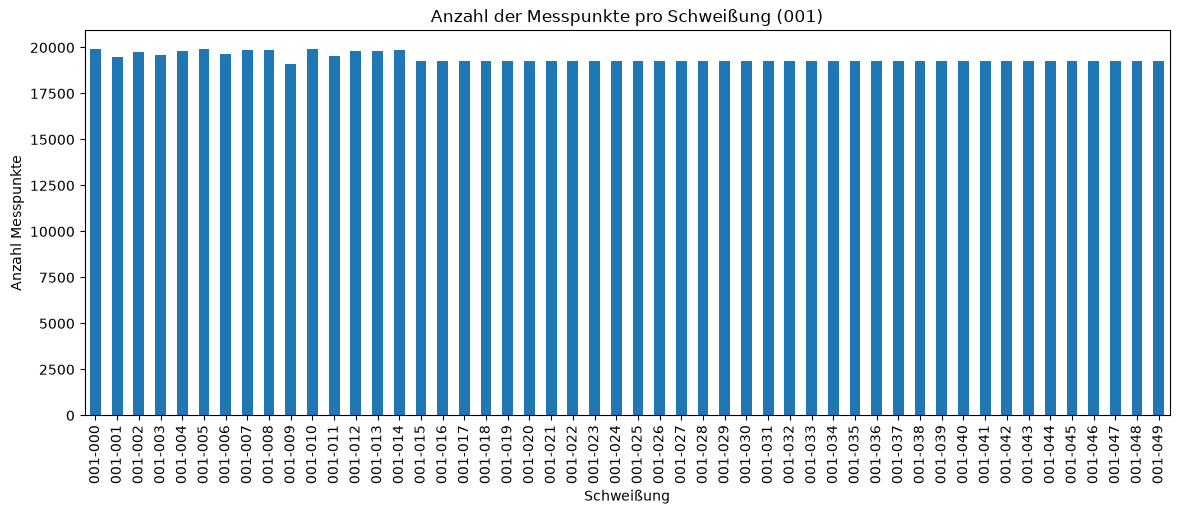

In [271]:
messpunkteProWelding = dataFrameAlleDataFrames001.groupby("ID").size()


plt.figure(figsize = (14, 5))

messpunkteProWelding.plot(kind = "bar")

plt.xlabel("Schweißung")
plt.ylabel("Anzahl Messpunkte")
plt.title("Anzahl der Messpunkte pro Schweißung (001)")
plt.show()